# Pipeline de Machine Learning com Dataset Real — Wine Quality

**Disciplina:** Inteligência Artificial — BCC / UNIFAL-MG

**Integrantes do grupo:** Jeann Victor Batista, Nicolas Rodrigues Teixeira de Oliveira, Enzo Maranezi

**Dataset escolhido:** Wine Quality (Vinho Verde tinto — `winequality-red.csv`), UCI Machine Learning Repository

**Tarefa de ML:** Regressão — prever a nota de qualidade sensorial do vinho (escala 0–10) a partir de 11 atributos físico-químicos (acidez, açúcar residual, cloretos, dióxido de enxofre, densidade, pH, sulfatos, teor alcoólico, etc.)

**Descrição resumida do problema:** O dataset contém 1599 amostras de vinho tinto "Vinho Verde" português. Cada amostra possui 11 variáveis de entrada obtidas por testes físico-químicos objetivos e uma variável de saída (`quality`) baseada na mediana de avaliações sensoriais feitas por especialistas (nota de 0 a 10). O objetivo é construir um pipeline completo — EDA, pré-processamento, treinamento/comparação de modelos e avaliação final — para estimar a qualidade do vinho a partir de suas propriedades físico-químicas.

> **Observação sobre uso de IA generativa:** conforme permitido no enunciado, este notebook foi estruturado com o auxílio de uma ferramenta de IA generativa (Claude, Anthropic) para apoiar a codificação. Essa utilização deve ser declarada também no relatório em PDF. O grupo é responsável por revisar, entender e ser capaz de explicar todo o conteúdo entregue.


## 1. Imports e Configuração

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Bibliotecas carregadas com sucesso.")


/home/jeann/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Bibliotecas carregadas com sucesso.


## 2. Carregamento do Dataset

In [2]:
# O CSV original usa ';' como separador de colunas
df = pd.read_csv("winequality-red.csv", sep=";")

print(f"Formato do dataset: {df.shape[0]} instâncias, {df.shape[1]} atributos (incluindo o alvo)")
df.head()


Formato do dataset: 1599 instâncias, 12 atributos (incluindo o alvo)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## 3. Análise Exploratória de Dados (EDA)

**Variável-alvo:** `quality` (inteiro, 0–10, embora na prática só apareçam notas entre 3 e 8 neste dataset).
**Variáveis de entrada:** 11 atributos numéricos contínuos (não há variáveis categóricas neste dataset).


In [5]:
# 3.1 Valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes no dataset: {df.isnull().sum().sum()}")


Valores ausentes por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores ausentes no dataset: 0


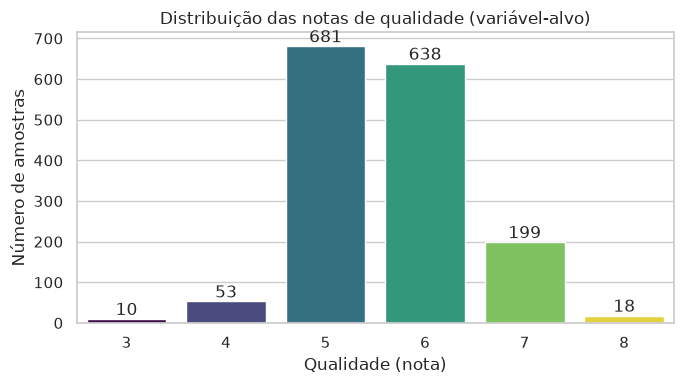

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [6]:
# 3.2 Distribuição da variável-alvo (desbalanceamento de classes)
plt.figure(figsize=(7, 4))
ax = sns.countplot(x="quality", data=df, hue="quality", palette="viridis", legend=False)
plt.title("Distribuição das notas de qualidade (variável-alvo)")
plt.xlabel("Qualidade (nota)")
plt.ylabel("Número de amostras")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

print(df["quality"].value_counts().sort_index())


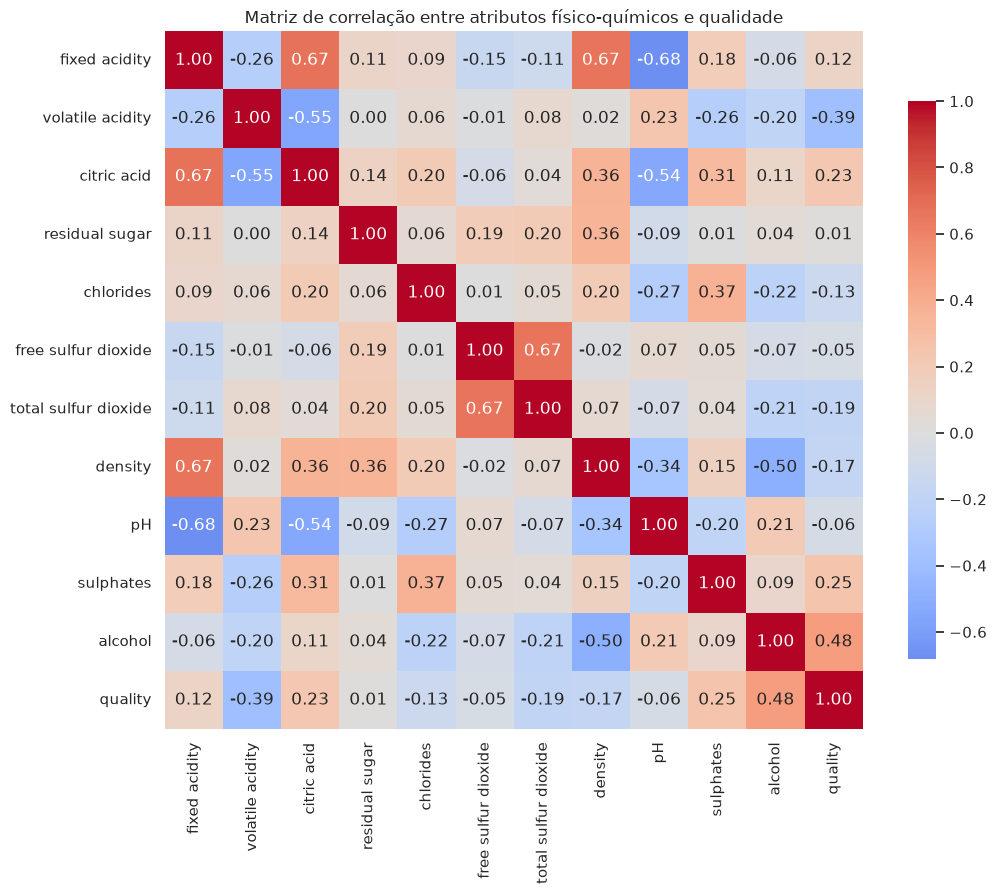

In [7]:
# 3.3 Matriz de correlação entre os atributos
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlação entre atributos físico-químicos e qualidade")
plt.tight_layout()
plt.show()


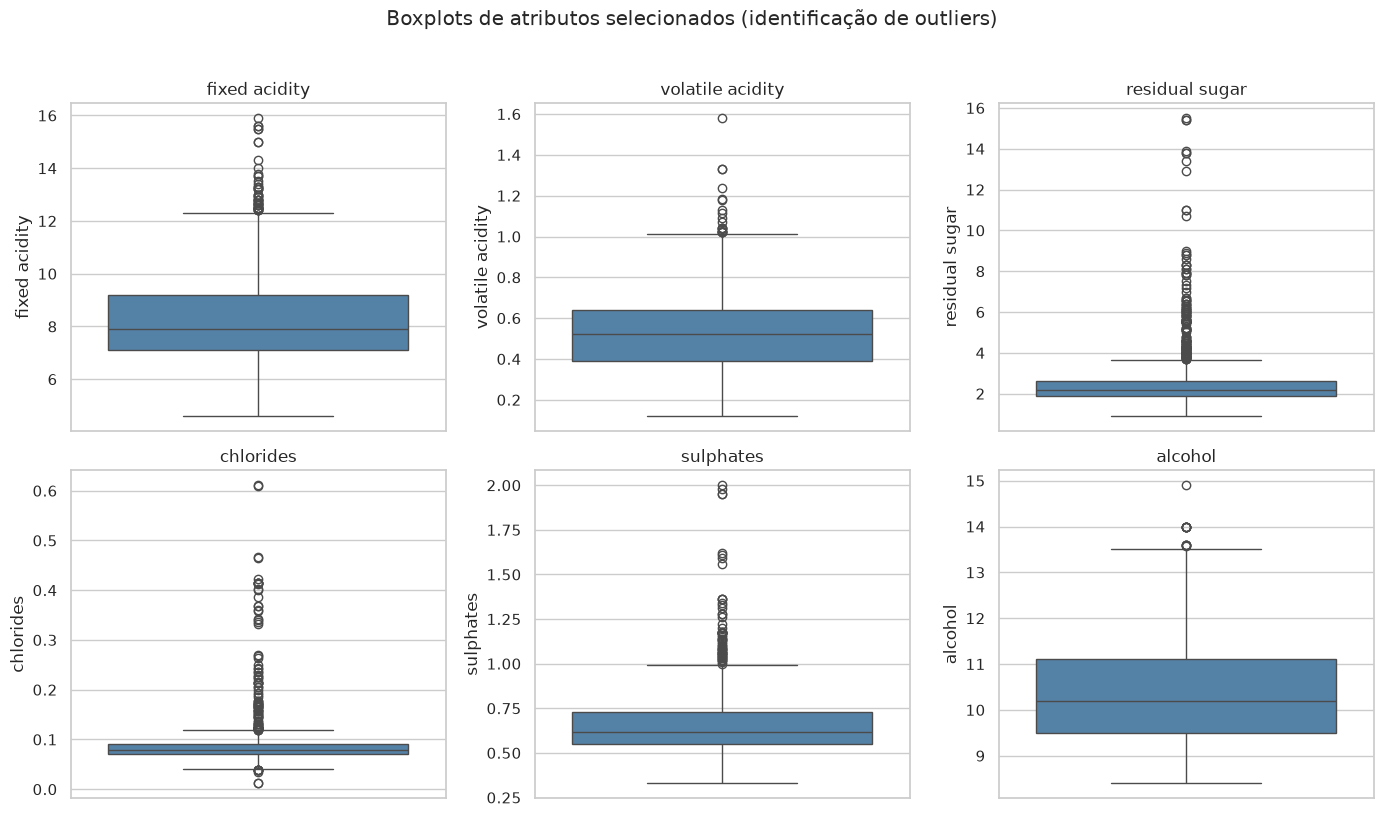

Quantidade de outliers (regra IQR 1.5x) por atributo:
  fixed acidity            :   49 outliers (3.1%)
  volatile acidity         :   19 outliers (1.2%)
  citric acid              :    1 outliers (0.1%)
  residual sugar           :  155 outliers (9.7%)
  chlorides                :  112 outliers (7.0%)
  free sulfur dioxide      :   30 outliers (1.9%)
  total sulfur dioxide     :   55 outliers (3.4%)
  density                  :   45 outliers (2.8%)
  pH                       :   35 outliers (2.2%)
  sulphates                :   59 outliers (3.7%)
  alcohol                  :   13 outliers (0.8%)


In [8]:
# 3.4 Boxplots para identificação de outliers em algumas variáveis-chave
features_outliers = ["fixed acidity", "volatile acidity", "residual sugar",
                      "chlorides", "sulphates", "alcohol"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), features_outliers):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(col)
plt.suptitle("Boxplots de atributos selecionados (identificação de outliers)", y=1.02)
plt.tight_layout()
plt.show()

# Quantificação de outliers via IQR
print("Quantidade de outliers (regra IQR 1.5x) por atributo:")
for col in df.columns[:-1]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col:25s}: {n_out:4d} outliers ({100*n_out/len(df):.1f}%)")


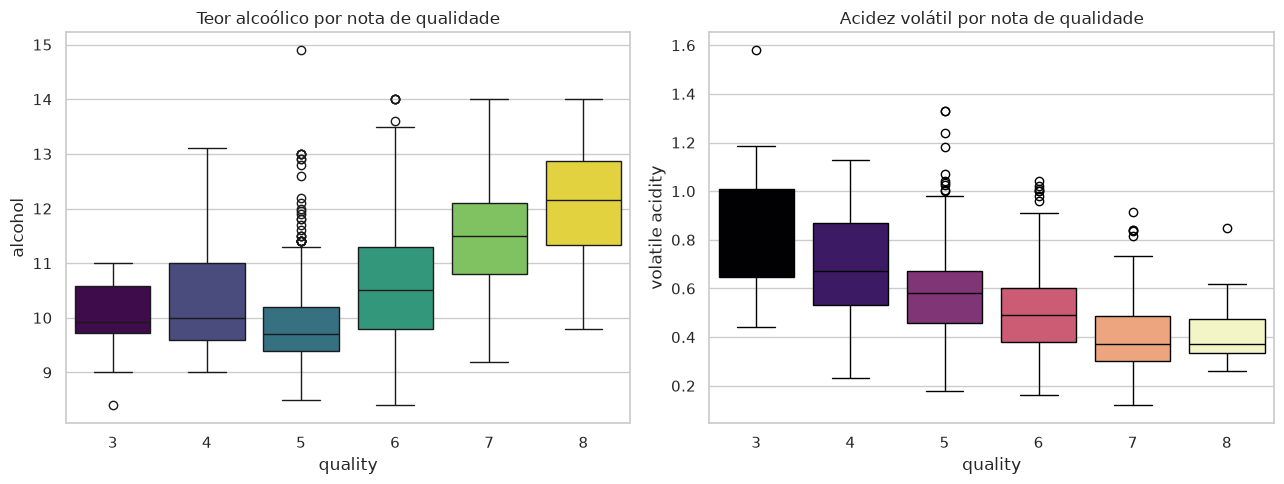

In [9]:
# 3.5 Relação entre teor alcoólico / acidez volátil e a qualidade
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x="quality", y="alcohol", data=df, hue="quality", palette="viridis",
            legend=False, ax=axes[0])
axes[0].set_title("Teor alcoólico por nota de qualidade")

sns.boxplot(x="quality", y="volatile acidity", data=df, hue="quality", palette="magma",
            legend=False, ax=axes[1])
axes[1].set_title("Acidez volátil por nota de qualidade")

plt.tight_layout()
plt.show()


### Insights da EDA

1. **Desbalanceamento acentuado da variável-alvo:** as notas de qualidade se concentram fortemente em torno de 5 e 6 (juntas somam mais de 80% das amostras), enquanto notas extremas (3, 4, 7, 8) são raras. Isso indica que, embora o problema seja tratado como regressão, o modelo tenderá a "regredir à média" e terá mais dificuldade para acertar vinhos muito bons ou muito ruins — é importante avaliar o erro por faixa de qualidade, não apenas globalmente.
2. **Teor alcoólico e acidez volátil são os atributos mais relevantes:** a matriz de correlação mostra que `alcohol` tem a correlação positiva mais forte com `quality`, enquanto `volatile acidity` tem correlação negativa notável. Os boxplots confirmam: vinhos com nota mais alta tendem a ter maior teor alcoólico e menor acidez volátil. Isso sugere que esses dois atributos devem ter bastante peso na modelagem (ex.: em importância de features de uma Random Forest).
3. **Presença de outliers em várias variáveis (ex.: `residual sugar`, `chlorides`, `sulphates`)**, mas em proporção pequena (poucos %). Como modelos como Random Forest são robustos a outliers e não removeremos amostras (poucos dados), optamos por manter os outliers, mas usar padronização (`StandardScaler`) para não distorcer os modelos lineares.


## 4. Pré-processamento

**Decisões e justificativas:**
- **Valores ausentes:** o dataset não possui nenhum valor ausente (confirmado na seção EDA), portanto nenhuma estratégia de imputação é necessária.
- **Variáveis categóricas:** não há variáveis categóricas neste dataset (todos os 11 atributos de entrada são numéricos contínuos), portanto não é necessário One-Hot/Label/Ordinal Encoding.
- **Padronização:** aplicamos `StandardScaler` às variáveis numéricas, já que os atributos têm escalas muito diferentes (ex.: `total sulfur dioxide` chega a centenas, enquanto `chlorides` é da ordem de 0.01–0.1). Isso é essencial para modelos baseados em distância/gradiente (ex.: Regressão Linear) e não prejudica modelos baseados em árvores.
- **Divisão treino/teste:** feita **antes** de qualquer ajuste de pré-processamento, para evitar data leakage. O `StandardScaler` é encapsulado em um `Pipeline` do scikit-learn e ajustado (`fit`) apenas no conjunto de treino; no conjunto de teste apenas aplicamos `transform`.


In [10]:
# 4.1 Separação treino (80%) / teste (20%) ANTES de qualquer pré-processamento
X = df.drop(columns=["quality"])
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")


Treino: 1279 amostras | Teste: 320 amostras


In [11]:
# 4.2 Pipeline de pré-processamento (ColumnTransformer + StandardScaler)
# Todas as colunas são numéricas neste dataset
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
    ]
)

print("Pré-processador definido. Ele será encapsulado dentro do Pipeline de cada modelo,")
print("garantindo que fit() ocorra somente sobre o treino em cada fold da validação cruzada.")


Pré-processador definido. Ele será encapsulado dentro do Pipeline de cada modelo,
garantindo que fit() ocorra somente sobre o treino em cada fold da validação cruzada.


## 5. Baseline

Como baseline simples, usamos um `DummyRegressor` que sempre prevê a média da variável-alvo no conjunto de treino. Qualquer modelo "de verdade" precisa superar esse baseline para ser considerado útil.


In [12]:
# quality é um inteiro discreto (3-8) e desbalanceado (ver EDA); estratificamos
# diretamente pelos seus valores para preservar a proporção de cada nota em cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])

baseline_cv = cross_validate(baseline_pipeline, X_train, y_train, cv=cv, scoring=scoring)

print("Baseline (DummyRegressor - média) - validação cruzada (k=5) no treino:")
print(f"  MAE  : {-baseline_cv['test_MAE'].mean():.3f} (+/- {baseline_cv['test_MAE'].std():.3f})")
print(f"  RMSE : {-baseline_cv['test_RMSE'].mean():.3f} (+/- {baseline_cv['test_RMSE'].std():.3f})")
print(f"  R2   : {baseline_cv['test_R2'].mean():.3f} (+/- {baseline_cv['test_R2'].std():.3f})")


Baseline (DummyRegressor - média) - validação cruzada (k=5) no treino:
  MAE  : 0.684 (+/- 0.004)
  RMSE : 0.807 (+/- 0.007)
  R2   : -0.000 (+/- 0.000)


## 6. Treinamento e Comparação de Modelos

Treinamos dois algoritmos estudados na disciplina:
- **Regressão Linear**, como modelo simples e interpretável;
- **Random Forest Regressor**, como modelo não-linear baseado em ensemble de árvores.

Ambos são avaliados por **validação cruzada com k=5 folds** sobre o conjunto de treino.

> **Nota metodológica:** conforme exigido no enunciado, a validação cruzada é **estratificada** (`StratifiedKFold`, k=5). Embora a tarefa seja de regressão, a variável-alvo `quality` é, na prática, um inteiro discreto e desbalanceado (poucas amostras nas notas 3, 4 e 8, ver Seção 3). Por isso, estratificamos os folds diretamente pelos valores observados de `quality`, garantindo que cada fold preserve a mesma proporção de cada nota presente no conjunto de treino — o que torna a comparação entre modelos mais justa e reprodutível.


In [13]:
models = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    results.append({
        "Modelo": name,
        "MAE": -cv_res["test_MAE"].mean(),
        "MAE_std": cv_res["test_MAE"].std(),
        "RMSE": -cv_res["test_RMSE"].mean(),
        "RMSE_std": cv_res["test_RMSE"].std(),
        "R2": cv_res["test_R2"].mean(),
        "R2_std": cv_res["test_R2"].std(),
    })

results.append({
    "Modelo": "Baseline (média)",
    "MAE": -baseline_cv["test_MAE"].mean(),
    "MAE_std": baseline_cv["test_MAE"].std(),
    "RMSE": -baseline_cv["test_RMSE"].mean(),
    "RMSE_std": baseline_cv["test_RMSE"].std(),
    "R2": baseline_cv["test_R2"].mean(),
    "R2_std": baseline_cv["test_R2"].std(),
})

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df


,Modelo,MAE,MAE_std,RMSE,RMSE_std,R2,R2_std
0,Random Forest,0.425471,0.015890,0.593267,0.028919,0.457816,0.051349
1,Regressão Linear,0.504103,0.008210,0.658447,0.013345,0.333283,0.024767
2,Baseline (média),0.683701,0.003938,0.806561,0.007300,-0.000039,0.000048


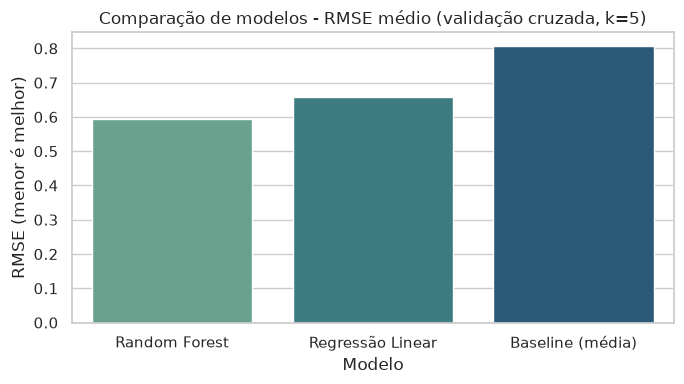

In [14]:
# Visualização comparativa dos modelos (RMSE, menor é melhor)
plt.figure(figsize=(7, 4))
sns.barplot(x="Modelo", y="RMSE", data=results_df, hue="Modelo", palette="crest", legend=False)
plt.title("Comparação de modelos - RMSE médio (validação cruzada, k=5)")
plt.ylabel("RMSE (menor é melhor)")
plt.tight_layout()
plt.show()


A **Random Forest** apresenta desempenho consistentemente melhor que a Regressão Linear e que o baseline (menor MAE/RMSE e maior R²), capturando relações não-lineares entre os atributos físico-químicos e a qualidade sensorial. Por isso, ela é escolhida como **modelo candidato** para o ajuste fino de hiperparâmetros.


## 7. Ajuste de Hiperparâmetros (GridSearchCV)

Aplicamos `GridSearchCV` sobre o melhor modelo candidato (Random Forest), buscando a melhor combinação de número de árvores, profundidade máxima e tamanho mínimo de folha, novamente com validação cruzada k=5 sobre o conjunto de treino.


In [15]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:")
print(grid_search.best_params_)
print(f"\nMelhor RMSE médio (validação cruzada): {-grid_search.best_score_:.3f}")


Melhores hiperparâmetros encontrados:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}

Melhor RMSE médio (validação cruzada): 0.591


## 8. Avaliação Final no Conjunto de Teste (hold-out)

O modelo final (com os melhores hiperparâmetros) é avaliado no conjunto de teste, que **não foi usado** em nenhuma etapa de treinamento ou seleção de hiperparâmetros.


In [16]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Desempenho do modelo final no conjunto de teste (hold-out):")
print(f"  MAE  : {mae:.3f}")
print(f"  RMSE : {rmse:.3f}")
print(f"  R2   : {r2:.3f}")


Desempenho do modelo final no conjunto de teste (hold-out):
  MAE  : 0.426
  RMSE : 0.556
  R2   : 0.528


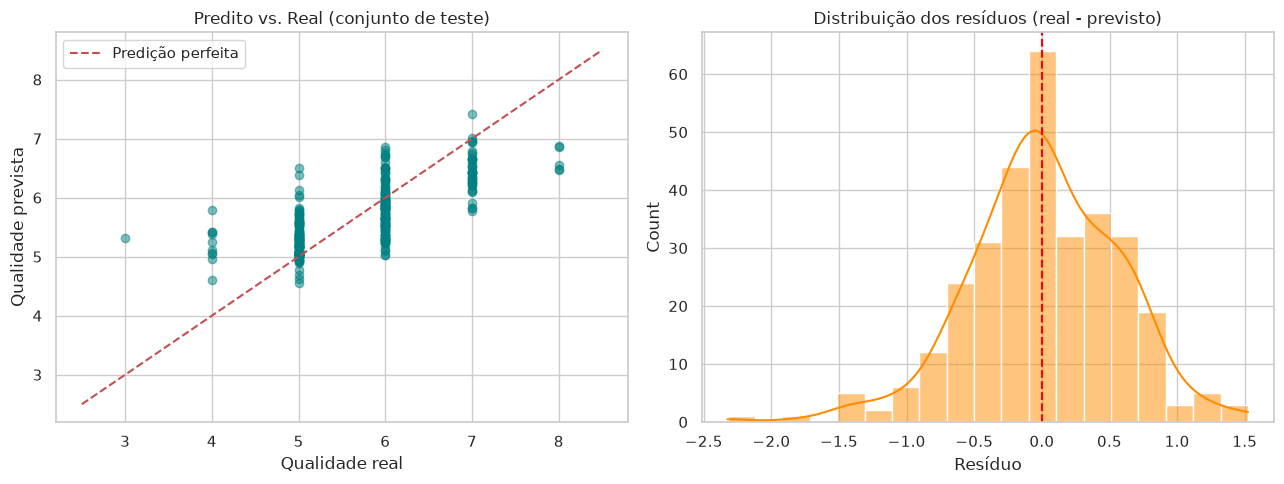

In [17]:
# Predito vs. Real e distribuição dos resíduos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, color="teal")
lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
axes[0].plot(lims, lims, "r--", label="Predição perfeita")
axes[0].set_xlabel("Qualidade real")
axes[0].set_ylabel("Qualidade prevista")
axes[0].set_title("Predito vs. Real (conjunto de teste)")
axes[0].legend()

residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color="darkorange")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribuição dos resíduos (real - previsto)")
axes[1].set_xlabel("Resíduo")

plt.tight_layout()
plt.show()


## 9. Análise de Erros

Erro médio absoluto por nota de qualidade real:
              MAE_medio  n_amostras
quality_real                       
3              2.324000           1
4              1.202891          10
5              0.316961         130
6              0.377456         132
7              0.574173          42
8              1.351641           5


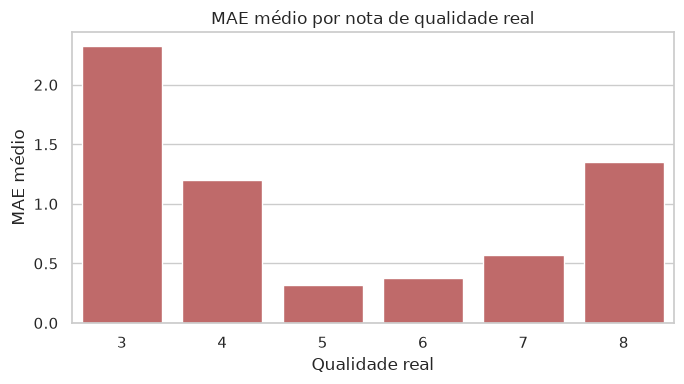

In [18]:
# Erro absoluto por faixa de qualidade real
error_df = pd.DataFrame({
    "quality_real": y_test.values,
    "quality_predita": y_pred,
    "erro_absoluto": np.abs(y_test.values - y_pred),
})

erro_por_qualidade = error_df.groupby("quality_real")["erro_absoluto"].agg(["mean", "count"])
erro_por_qualidade.columns = ["MAE_medio", "n_amostras"]
print("Erro médio absoluto por nota de qualidade real:")
print(erro_por_qualidade)

plt.figure(figsize=(7, 4))
sns.barplot(x=erro_por_qualidade.index, y=erro_por_qualidade["MAE_medio"], color="indianred")
plt.title("MAE médio por nota de qualidade real")
plt.xlabel("Qualidade real")
plt.ylabel("MAE médio")
plt.tight_layout()
plt.show()


In [19]:
# As 10 maiores instâncias de erro
top_errors = error_df.sort_values("erro_absoluto", ascending=False).head(10)
top_errors


,quality_real,quality_predita,erro_absoluto
11,3,5.324000,2.324000
186,4,5.785893,1.785893
110,8,6.476000,1.524000
142,8,6.477793,1.522207
185,5,6.504000,1.504000
76,8,6.556000,1.444000
89,4,5.418000,1.418000
38,4,5.416861,1.416861
288,4,5.390167,1.390167
133,5,6.380000,1.380000


**Padrão observado:** o erro médio absoluto é claramente maior nas notas extremas (3, 4, 7, 8) do que nas notas centrais (5, 6). Isso é coerente com o desbalanceamento identificado na EDA: como há poucas amostras com notas muito baixas ou muito altas, o modelo tem menos exemplos para aprender esses padrões e tende a "puxar" suas previsões em direção à média (5–6), errando mais nos extremos.


## 10. Limitações e Melhorias Futuras

**Limitações:**
- O dataset possui um desbalanceamento significativo na variável-alvo, com poucas amostras de vinhos de qualidade muito baixa ou muito alta. Isso limita a capacidade do modelo de generalizar bem para esses casos extremos, que são justamente os mais interessantes na prática (identificar vinhos excepcionais ou defeituosos).
- A variável-alvo é a mediana de avaliações subjetivas de especialistas, o que introduz um limite superior de desempenho: mesmo humanos discordam entre si na avaliação sensorial, então nenhum modelo baseado apenas em atributos físico-químicos deve esperar acertar perfeitamente.
- Não há dados sobre tipo de uva, marca ou preço do vinho (removidos por questões de privacidade/logística), que poderiam ser preditores relevantes da qualidade.

**Possíveis melhorias futuras:**
- Utilizar técnicas de balanceamento voltadas para regressão (ex.: SMOGN) para dar mais peso às amostras raras (notas extremas).
- Testar outros algoritmos como Gradient Boosting (XGBoost/LightGBM) e realizar uma busca de hiperparâmetros mais ampla (ex.: `RandomizedSearchCV` com mais combinações).
- Combinar os datasets de vinho tinto e branco (com uma variável indicadora de tipo) para aumentar o volume de dados de treinamento.


## 11. Conclusão

Este notebook conduziu um pipeline completo de Machine Learning sobre o dataset Wine Quality (tinto), cobrindo EDA, pré-processamento sem data leakage (via `Pipeline`/`ColumnTransformer`), comparação de modelos com validação cruzada, ajuste de hiperparâmetros via `GridSearchCV` e avaliação final em conjunto de teste hold-out. O modelo Random Forest superou o baseline e a Regressão Linear em todas as métricas (MAE, RMSE, R²), confirmando que existem relações não-lineares relevantes entre os atributos físico-químicos e a qualidade sensorial do vinho. A principal limitação identificada foi o desbalanceamento da variável-alvo, que concentra o erro do modelo nas notas extremas — um ponto de partida natural para trabalhos futuros.
